# Clustering audio à partir des fichiers chroma

On utilise ici les features de Chordino qui permettent d'étudier les accords.

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import plotly.express as px
from plotly.offline import plot
import plotly.io as pio
from sklearn.manifold import MDS
import librosa
from scipy.cluster.hierarchy import linkage, dendrogram
import os
import importlib
import oeuvre
importlib.reload(oeuvre)
from oeuvre import Oeuvre

In [164]:
dico_res = {"maj":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0],
"min":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0],
"dim_dim7":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0],
"dim_min7":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0],
"maj_min7":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0],
"maj_maj7":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1],
"min_min7":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0],
"dim":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0],
"aug":[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0]}

In [165]:
dico_notes = {
    "A" : 0,
    "A#" : 1,
    "Bb" : 1,
    "B" : 2,
    "C" : 3,
    "C#" : 4,
    "Db" : 4,
    "D" : 5,
    "D#" : 6,
    "Eb" : 6,
    "E" : 7,
    "F" : 8,
    "F#" : 9,
    "Gb" : 9,
    "G" : 10,
    "G#" : 11,
    "Ab" : 11,
    "N" : -1
}

In [166]:
li_filenames = []

for racine, _, fichiers in os.walk('cross-era_chords-chordino'):
    for fichier in fichiers:
        chemin_relatif = os.path.relpath(os.path.join(racine, fichier))
        li_filenames.append(chemin_relatif)

## Récupération d'un fichier et transformation en features

In [194]:
def get_matrix(chunk):
    li = []
    i = -1
    tonalite = chunk[-1].split("_")[0]
    while tonalite == 'N':
        i -= 1
        tonalite = chunk[i].split("_")[0]
    ind_tonalite = dico_notes[tonalite]
    for accord in chunk:
        partition = accord.split("_")
        note = partition[0]
        if dico_notes[note] > 0:
            liste = [0]*12
            liste[(dico_notes[note] - ind_tonalite)%12]=1
            acc = "_".join(partition[1:])
            liste += dico_res[acc]
            li.append(liste)
    return np.array(li).flatten()

In [168]:
def get_chunks(filename):
    data = pd.read_csv(filename, sep=",", header=None)
    chunks = {}
    chunk = []
    title = None
    for i, row in data.iterrows():
        if pd.notna(row[0]):
            if title is not None:
                chunks[title] = chunk
            title = row[0]
            chunk = []
        else:
            chunk.append(row[2])
    
    if title is not None:
        chunks[title] = chunk
    return chunks

def dico_chunks(filename):
    chunks = get_chunks(filename)
    return {k: get_matrix(v) for k, v in chunks.items() if len(v) > 0}

In [195]:
li = get_chunks(li_filenames[0])
morc = li['orchestra_addon/CrossEra-1601_Bach_CPE_sinfonia_in_a_major_wq._182_no._4.mp3']
print(morc)
get_matrix(morc)

['F#_maj', 'B_min', 'A_maj_maj7', 'D_maj', 'A_maj', 'A_aug', 'B_min', 'E_maj_maj7', 'C#_min', 'F#_maj_min7', 'B_maj', 'E_maj', 'A_min', 'B_maj_min7', 'C#_min_min7', 'C_maj_maj7', 'A_maj', 'E_maj', 'F#_maj', 'B_min', 'A_maj_maj7', 'D_maj', 'A_maj', 'A_aug', 'B_min', 'E_maj_maj7', 'C#_min', 'F#_maj_min7', 'B_maj', 'E_maj', 'A_min', 'B_maj_min7', 'C#_min_min7', 'C_maj_maj7', 'A_maj', 'E_maj', 'C#_maj', 'F#_min', 'A_dim_dim7', 'C#_min', 'Ab_maj', 'C#_min', 'Ab_maj', 'C#_min', 'A_maj_min7', 'D_maj_maj7', 'G_maj_maj7', 'E_maj_maj7', 'C#_dim', 'F#_min', 'D_maj', 'Ab_dim_min7', 'C#_min', 'F#_min_min7', 'B_min_min7', 'E_maj', 'A_maj', 'D_min', 'F#_min_min7', 'D_maj', 'E_maj', 'D_maj', 'A_maj', 'C#_maj', 'F#_min', 'A_dim_dim7', 'C#_min', 'Ab_maj', 'A_maj_maj7', 'Ab_maj', 'C#_min', 'A_maj_min7', 'D_maj_maj7', 'G_maj_maj7', 'Ab_min_min7', 'C#_min_min7', 'F#_min', 'A_maj_min7', 'D_maj', 'Ab_dim_min7', 'C#_min', 'F#_min_min7', 'B_min_min7', 'E_maj', 'A_maj', 'D_min', 'F#_min_min7', 'D_maj', 'E_maj',

array([0, 0, 0, ..., 0, 1, 0])

## Création des objets

In [169]:
def construct_oeuvre(name,matrix = None):
    oeuvre = Oeuvre(name)
    oeuvre.filename = name
    name = name[:-3]
    part1 = name.split("/")
    cat = part1[0].split("_")
    oeuvre.category = cat[0]
    oeuvre.genre = cat[1]
    part2 = part1[1].split("_")[1:]
    oeuvre.compositeur = part2[0]
    oeuvre.titre = " ".join(part2[1:])
    oeuvre.matrix = matrix
    return oeuvre

In [170]:
print(construct_oeuvre("piano_classical/CrossEra-1001_Cimarosa_Piano_sonata_no._10_in_b-flat_major___allegro.mp3"))

Cimarosa - Piano sonata no. 10 in b-flat major   allegro. - classical


In [171]:
def li_oeuvres(filename):
    dico = dico_chunks(filename)
    return [construct_oeuvre(k,v) for k,v in dico.items()]

def encyclo_oeuvres(filenames):
    li = []
    for filename in filenames:
        li += li_oeuvres(filename)
        print(f"{filename} fait")
    return li

In [172]:
liste_oeuvres = encyclo_oeuvres(li_filenames)

cross-era_chords-chordino\chords-chordino_orchestra_addon.csv fait
cross-era_chords-chordino\chords-chordino_orchestra_baroque.csv fait
cross-era_chords-chordino\chords-chordino_orchestra_classical.csv fait
cross-era_chords-chordino\chords-chordino_orchestra_modern.csv fait
cross-era_chords-chordino\chords-chordino_orchestra_romantic.csv fait
cross-era_chords-chordino\chords-chordino_piano_addon.csv fait
cross-era_chords-chordino\chords-chordino_piano_baroque.csv fait
cross-era_chords-chordino\chords-chordino_piano_classical.csv fait
cross-era_chords-chordino\chords-chordino_piano_modern.csv fait
cross-era_chords-chordino\chords-chordino_piano_romantic.csv fait


## Clustering

In [173]:
def transpose(mat1,k):
    n,_ = mat1.shape
    mat2 = mat1.copy()
    for i in range(n):
        for j in range(12):
            if mat1[i,j]==1:
                mat2[i,j]=0
                mat2[i,(j+k)%12]=1
    return mat2

In [174]:
oeuvre2 = liste_oeuvres[0]
print(oeuvre2.matrix[0])
print(transpose(oeuvre2.matrix,3)[0])

[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0]
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0]


In [175]:
def dist_brute(mat1,mat2,dec = 0):
    assert len(mat1) <= len(mat2)
    m1 = mat1
    m2 = mat2[dec:dec+len(mat1),:]
    return np.mean((m2-m1)**2)

def distance(o1,o2):
    if len(o1.matrix)<=len(o2.matrix):
        m1 = o1.matrix
        m2 = o2.matrix
    else:
        m1 = o2.matrix
        m2 = o1.matrix
    return min([min([dist_brute(m1,transpose(m2,transposition),dec) for dec in range(len(m2)-len(m1)+1)]) for transposition in range(12)])

In [ ]:
def petite_distance(mat1,mat2):
    

In [178]:
import random

liste_oeuvres = random.sample(liste_oeuvres, 30)

In [179]:
matrices = np.array(liste_oeuvres)
dist = np.zeros((len(liste_oeuvres),len(liste_oeuvres)), dtype = float)

for (i,mat1) in enumerate(liste_oeuvres):
    for (j,mat2) in enumerate(liste_oeuvres):
            if i < j:
                dist[i,j] = distance(mat1,mat2)
                dist[j,i] = dist[i,j]
            print(i,mat1,j,mat2, dist[i,j])


scaler = StandardScaler()
normalized_matrix = scaler.fit_transform(dist)

with open("distance_matrix.pkl", "wb") as f:
    pickle.dump(dist, f)

kmeans = KMeans(n_clusters=5, random_state=42)  # Adjust n_clusters as needed
clusters = kmeans.fit_predict(normalized_matrix)

print(clusters)
first_cluster_oeuvres = [liste_oeuvres[i] for i in range(len(clusters)) if clusters[i] == 0]
print(first_cluster_oeuvres)

0 Milhaud - derniers feuillets. - modern 0 Milhaud - derniers feuillets. - modern 0.0
0 Milhaud - derniers feuillets. - modern 1 BachWTK1 - 2 06 - Das Wohltemperierte Klavier  Book 1 BWV 846-869 - Fugue in A flat major BWV 862. - baroque 0.07407407407407407
0 Milhaud - derniers feuillets. - modern 2 Clementi - sonata in b minor op. 40 no. 2molto adagio e sostenutoallegro con fuoco e con espressione. - classical 0.07175925925925926
0 Milhaud - derniers feuillets. - modern 3 Schubert - symph. no. 4 menuetto allegro vivace. - addon 0.04861111111111111
0 Milhaud - derniers feuillets. - modern 4 Brahms - Glenn Gould op10 ballade no4 b-major. - romantic 0.05092592592592592
0 Milhaud - derniers feuillets. - modern 5 Liszt - hamlet s104. - romantic 0.04861111111111111
0 Milhaud - derniers feuillets. - modern 6 Couperin - Francois Huitieme ordre  ix. rondeau passacaille. - baroque 0.06944444444444445
0 Milhaud - derniers feuillets. - modern 7 Brahms - sonata no.3 in f minor op.5 scherzo allegro

c:\Log_inst\Programmation-Anaconda\envs\MODAL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



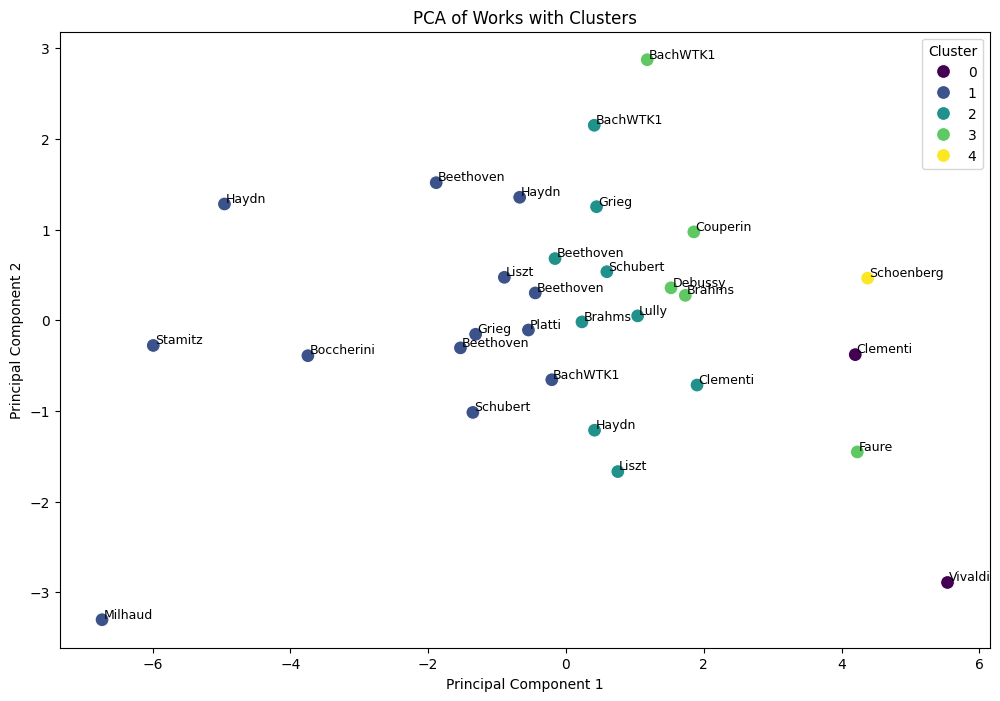

In [181]:
# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(normalized_matrix)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'PCA1': pca_result[:, 0],
    'PCA2': pca_result[:, 1],
    'Cluster': clusters,
    'Name': [oeuvre.compositeur for oeuvre in liste_oeuvres]
})

# Plot the PCA results
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='viridis', s=100
)

# Annotate each point with the name of the work
for i, row in pca_df.iterrows():
    plt.text(row['PCA1'] + 0.02, row['PCA2'] + 0.02, row['Name'], fontsize=9)

plt.title('PCA of Works with Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()